# Densities on faces: discontinuous Galerkin

A continuous finite element space needs one density, written on the cells. A discontinuous
one needs two more: a term on the **interior faces**, where the solution jumps, and one on the
**boundary**, where conditions are imposed weakly rather than on the space.

hIPPyMFEM takes them as separate functions with the same shape as the volume density:

```python
pde_varf  (u, m, p, x)          # dx: the cells
facet_varf(u, m, p, x, n, h)    # dS: the interior faces
bdr_varf  (u, m, p, x, n, h)    # ds: the boundary
```

On a face `u`, `m` and `p` carry two values, one from each side, and `jump`, `avg` and
`avg_grad` combine them; `n` is the face normal and `h` the two cell sizes. All three are
differentiated the same way, so the face terms reach the Jacobian, the parameter Jacobian and
every Hessian block without being mentioned again.

The problem here is transport of a plume at a **mesh Péclet number of about 16**, where the
upwind flux on the faces is what keeps the discrete solution in order, with the diffusivity
$\kappa e^{m}$ to be inferred from measurements downstream.

## 1. Load modules

In [1]:
import os
import sys

sys.path.insert(0, os.environ.get("HIPPYMFEM_BASE_DIR", os.path.abspath("..")))

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from mpi4py import MPI
import mfem.par as mfem
import jax.numpy as jnp

import hippymfem as hm
from hippymfem import nb
from hippymfem.fem.facets import avg, avg_grad, jump
from hippymfem.modeling.variables import STATE, PARAMETER, ADJOINT

## 2. A discontinuous space

`FunctionSpace.L2` is the discontinuous space: its dofs belong to one cell each, and nothing
ties neighbours together except the face terms we are about to write. The parameter stays
continuous, since the diffusivity field is not expected to jump.

In [2]:
WIND, KAPPA, PENALTY, ORDER = np.array([1.0, 0.3]), 2e-3, 20.0, 1
nx = 32

mesh = mfem.ParMesh(MPI.COMM_WORLD,
                    mfem.Mesh.MakeCartesian2D(nx, nx, mfem.Element.QUADRILATERAL))
Vu = hm.FunctionSpace.L2(mesh, ORDER)     # discontinuous state
Vm = hm.FunctionSpace.H1(mesh, 1)         # continuous parameter

print("DG state: %d dofs, parameter: %d dofs" % (Vu.GlobalTrueVSize(), Vm.GlobalTrueVSize()))
print("mesh Peclet number: %.1f" % (np.linalg.norm(WIND) / (nx * KAPPA)))

DG state: 4096 dofs, parameter: 1089 dofs
mesh Peclet number: 16.3


## 3. Three densities

- **Cells**: diffusion, and transport integrated by parts.
- **Interior faces**: the *upwind flux*, which takes the value from the side the wind blows
  from, and the symmetric interior penalty (SIPG) terms that make diffusion consistent across
  the jump. Note `avg(m)`: the parameter is continuous, but on a face it is still two values,
  and averaging says which one the flux uses.
- **Boundary**: one density for the whole boundary, with the sign of $b\cdot n$ deciding
  whether a point is inflow (data comes in, imposed weakly by Nitsche terms) or outflow (the
  state leaves). There are **no essential conditions**, so no `DirichletBC` is passed.

In [3]:
def inflow(x):
    return jnp.exp(-60.0 * (x[1] - 0.35) ** 2)


def pde_varf(u, m, p, x):                                   # dx
    return (KAPPA * jnp.exp(m.val) * hm.inner(u.grad, p.grad)
            - u.val * jnp.dot(jnp.asarray(WIND), p.grad))


def facet_varf(u, m, p, x, n, h):                           # dS
    bn = jnp.dot(jnp.asarray(WIND), n)
    k = KAPPA * jnp.exp(avg(m))
    upwind = (bn * avg(u) + 0.5 * jnp.abs(bn) * jump(u)) * jump(p)
    sipg = (-k * jnp.dot(avg_grad(u), n) * jump(p)
            - k * jump(u) * jnp.dot(avg_grad(p), n)
            + PENALTY * k * 0.5 * (1.0 / h[0] + 1.0 / h[1]) * jump(u) * jump(p))
    return upwind + sipg


def bdr_varf(u, m, p, x, n, h):                             # ds
    bn = jnp.dot(jnp.asarray(WIND), n)
    k = KAPPA * jnp.exp(m.val)
    d = u.val - inflow(x)
    advect = jnp.where(bn > 0.0, bn * u.val, bn * inflow(x)) * p.val
    nitsche = (-k * jnp.dot(u.grad, n) * p.val - k * d * jnp.dot(p.grad, n)
               + PENALTY * k * (1.0 / h) * d * p.val)
    return advect + jnp.where(bn < 0.0, nitsche, 0.0)


pde = hm.PDEVariationalProblem([Vu, Vm, Vu], pde_varf, None, None, is_fwd_linear=True,
                               quadrature_degree=2 * ORDER + 2,
                               facet_varf=facet_varf, bdr_varf=bdr_varf,
                               bdr_attributes="all")
pde.set_solvers(lambda: hm.LUSolver(MPI.COMM_WORLD))
print("no essential dofs: the inflow data is imposed weakly")

no essential dofs: the inflow data is imposed weakly


## 4. The plume

state range [0.0000, 0.9985] for an inflow profile that peaks at 1


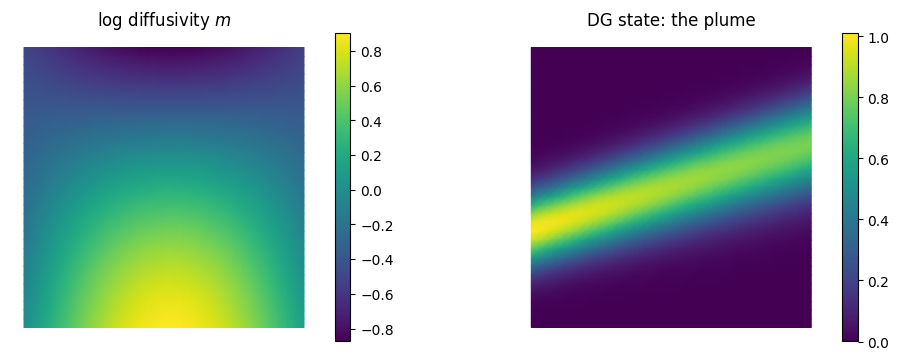

In [4]:
mtrue = Vm.project(lambda z: 0.9 * np.sin(3.0 * z[0]) * np.cos(2.0 * z[1]) - 0.5 * z[1])
utrue = pde.generate_state()
pde.solveFwd(utrue, [utrue, mtrue, None])

u = utrue.array
print("state range [%.4f, %.4f] for an inflow profile that peaks at 1" % (u.min(), u.max()))

plt.figure(figsize=(12, 4))
nb.plot(Vm, mtrue, subplot_loc=121, mytitle="log diffusivity $m$")
nb.plot(Vu, utrue, subplot_loc=122, mytitle="DG state: the plume")
plt.show()

## 5. The face terms are differentiated too

The diffusivity multiplies the interior-face flux and its penalty, so the parameter reaches
the answer *through* the face density as well as the cell one. A facet derivative that was
wrong, or simply missing, would show up as a wrong gradient, which is what `modelVerify`
measures: the first-order slope stays at 1 until finite differences run into round-off.

      eps  ||err grad||     ||err H||        J(m+h)       slope g


 1.00e+00  1.417091e+07  1.006113e+01  1.417101e+07             -


 5.00e-01  7.085440e+06  2.628448e+00  3.542833e+06        1.0000


 2.50e-01  3.542719e+06  1.656054e+00  8.857969e+05        1.0000


 1.25e-01  1.771359e+06  9.321884e-01  2.215392e+05        1.0000


...

 7.45e-09  1.091091e-01  1.719416e-04  1.212186e+02        0.9650


 3.73e-09  5.594561e-02  2.069892e-04  1.212186e+02        0.9637


 1.86e-09  4.269717e-02  1.034421e-03  1.212186e+02        0.3899


 9.31e-10  3.707430e-02  2.013606e-03  1.212186e+02        0.2037


 4.66e-10  5.871126e-02  3.916663e-03  1.212186e+02       -0.6632


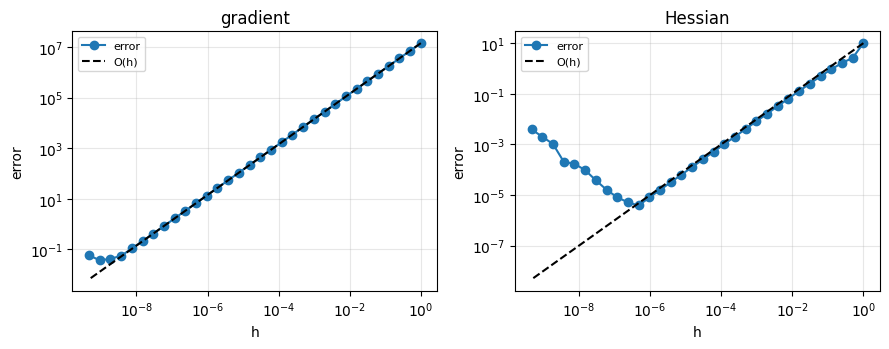

In [5]:
rng = np.random.default_rng(3)
targets = np.column_stack((rng.uniform(0.55, 0.95, 80), rng.uniform(0.05, 0.95, 80)))
B = hm.assemblePointwiseObservation(Vu, targets)
data = B.createVecLeft(); B.mult(utrue, data)
noise_std = 0.01 * data.norm("linf")
hm.parRandom.set_seed(4); B.perturb(data, noise_std)

model = hm.Model(pde, hm.BiLaplacianPrior(Vm, 1.0, 12.0, robin_bc=True),
                 hm.DiscreteStateObservation(B, data, noise_std ** 2))

eps, err_grad, err_H = hm.modelVerify(model, model.prior.mean.copy(), plotting=True)
plt.show()

## What to take from this

- A face density is written the same way a cell density is, and `jump`, `avg` and `avg_grad`
  are all the vocabulary needed for upwind fluxes, SIPG and Nitsche terms.
- Nothing downstream changes: the same `Model`, the same Newton-CG, the same posterior
  machinery, with the facet terms differentiated along with everything else.
- The library's `test_facets` suite checks the interior-penalty operator against MFEM's own
  `DGDiffusionIntegrator`, including faces shared between MPI ranks, and checks a DG inverse
  problem's gradient.

Next: [11_VectorAndMixedFields](11_VectorAndMixedFields.ipynb) takes the density to fields with
more than one component, and [12_ForwardUQ](12_ForwardUQ.ipynb) propagates a distribution
through the forward problem to a single predicted number.

`applications/dg/model_transport_dg.py` is this problem as a driver, with the inversion run to
convergence; `docs/source/guide/facets.rst` documents the facet interface.